# 성격 유형 분류 머신러닝
- 사람이 외향형인지 내향형인지 분류하는 모델 설계
- 데이터 확인 -> 전처리 -> 모델 학습 -> 평가 -> 성능 개선

데이터 출처 https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data
- 목차 
1. 데이터 불러오기
2. 탐색적 데이터 분석(EDA)
3. 데이터 전처리
4. 모델 구현
5. 성능 분석
6. 분류 모델 고도화
7. 추가 고도화 (Pipeline 기반 모델)

|컬럼 이름|컬럼 정보|값|
|---|---|---|
|Time_spent_Alone|매일 혼자 보낸 시간 |(0-11시간)|
|Stage_fear|스테이지 공포의 존재|(Yes/No)|
|Social_event_attendance|사회적 사건의 빈도|(0–10)|
|Going_outside|외출 빈도|(0–7)|
|Drained_after_socializing|사교 후 피로감을 느낍니다|(Yes/No)|
|Friends_circle_size|친한 친구의 수|(0–15)|
|Post_frequency|소셜 미디어 포스트 빈도|(0–10)|
|Personality|목표 변수|(Extrovert/Introvert)|

In [46]:
# 기본 데이터 처리 및 시각화
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 전처리 관련 라이브러리
from sklearn.preprocessing import LabelEncoder  # 범주형 변수 숫자로 변환
from sklearn.impute import SimpleImputer        # 결측치 대체 (예측하게 만드는 초소형 모델)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier   # KNN
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier       # XGBoost

# 데이터 분할 / 하이퍼파라미터 튜닝
from sklearn.model_selection import train_test_split, RandomizedSearchCV


## 1. 데이터불러오기

In [47]:
# 데이터 읽어오기
df = pd.read_csv('data/personality_datasert.csv', encoding='utf-8')

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [48]:
target = 'Personality'
features = [col for col in df.columns if col != target]

print(f"targer = {target}")
print(f"features = {features}")
len(features)

targer = Personality
features = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']


7

In [49]:
original_df = df.copy(deep=True)

print(f"데이터셋의 행수 : {df.shape[0]}, 열수 : {df.shape[1]} ")

데이터셋의 행수 : 2900, 열수 : 8 


## 2. 탐색적 데이터 분석(EDA)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [51]:
nf = []
cf = []

for col in features:
    if df[col].dtype in ['float64','int64','float32','int32']:
        nf.append(col)
    else:
        cf.append(col)

print(f"숫자형 데이터셋 개수 : {len(nf)}개 \n범주형 데이터셋 갯수 : {len(cf)}개")

숫자형 데이터셋 개수 : 5개 
범주형 데이터셋 갯수 : 2개


In [52]:
df[target].head()

0    Extrovert
1    Introvert
2    Introvert
3    Extrovert
4    Extrovert
Name: Personality, dtype: str

In [53]:
df[target].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

### 기본 정보 확인후
- 타겟 클래스가 한쪽으로 치우쳐 있는지
- 숫자형 변수들 분포가 왜도가 있는지
- 변수 간 상관관계가 강하게 있는지
- 범주형 변수와 타겟의 관계

In [54]:
df.isna().sum()   # 결측치 없음

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [55]:
# 클래스 불균형 분석

personality_counts = df[target].value_counts()

# 고유값 별 비율 환산하여 * 100 = % 단위로 확인
personality_percentage = df['Personality'].value_counts(normalize= True) *100 # normalize= True : 비율로 환산해줌

for class_val, percentage in personality_percentage.items():
    print(f"클래스 : {class_val}, 비율 : {percentage:.4f}")

클래스 : Extrovert, 비율 : 51.4138
클래스 : Introvert, 비율 : 48.5862


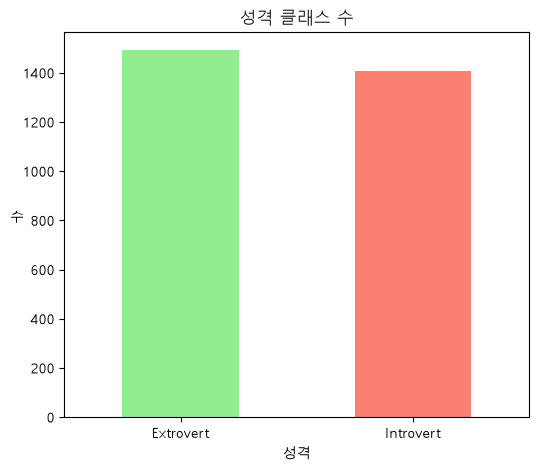

In [56]:
# 클래스 분포 막대그래프 시각화

plt.figure(figsize=(6,5))
personality_counts.plot(kind = 'bar', color = ['lightgreen','salmon'])
plt.title("성격 클래스 수")
plt.xlabel('성격')
plt.xticks(rotation = 0)
plt.ylabel('수',rotation = 0)
plt.tight_layout
plt.show()

In [57]:
# 수치형 변수 통계(+전치)
df[nf].describe().T

,count,mean,std,min,25%,50%,75%,max
Time_spent_Alone,2900.0,4.505816,3.441180,0.0,2.0,4.000000,7.0,11.0
Social_event_attendance,2900.0,3.963354,2.872608,0.0,2.0,3.963354,6.0,10.0
Going_outside,2900.0,3.000000,2.221597,0.0,1.0,3.000000,5.0,7.0
Friends_circle_size,2900.0,6.268863,4.232340,0.0,3.0,5.000000,10.0,15.0
Post_frequency,2900.0,3.564727,2.893587,0.0,1.0,3.000000,6.0,10.0


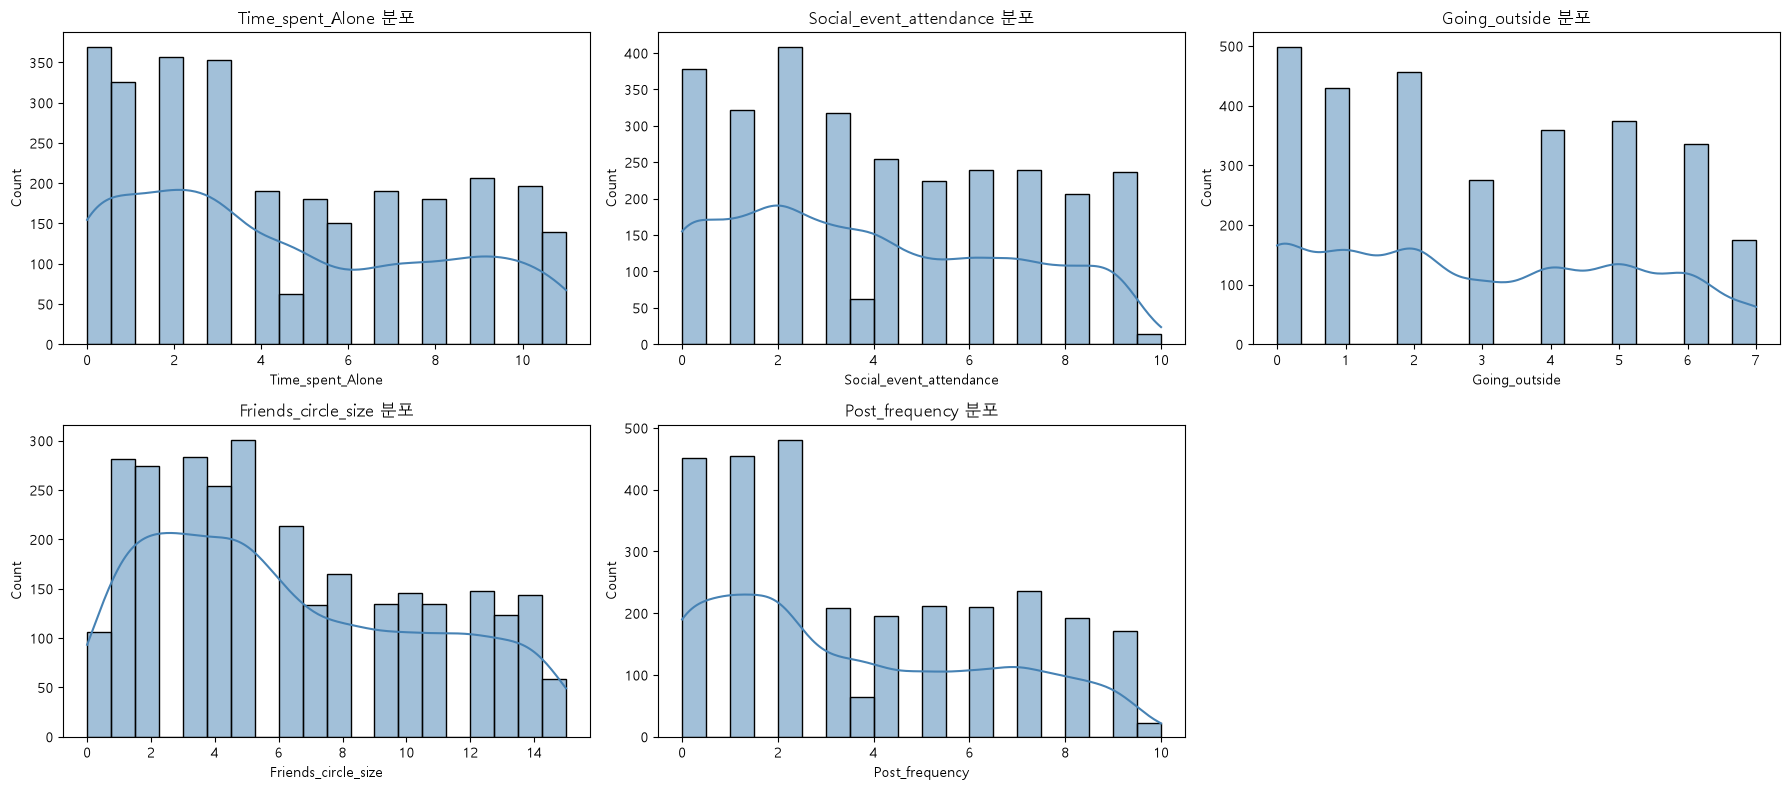

In [58]:
# 숫자형 컬럼들 분포 히스토그램 시각화
import math

n_cols = 3                            # 서브 플롯 열 수
n_features = len(nf) 
n_rows = math.ceil(n_features/n_cols) # 서브 플롯 행 수

fig, axes = plt.subplots(n_rows, n_cols, figsize =(6 * n_cols, 4 * n_rows)) # (2,3) / 전체 사이즈는 행과 열에 의해 유동적
axes = axes.flatten()  # flatten : axes[i][j] => axes[i] 2차원배열을 1차원배열로 변환

for i ,col in enumerate(nf):
    sns.histplot(
        df[col].dropna(),
        bins = 20,      # 20개 구간
        kde = True,     # kde 곡선
        ax = axes[i],   
        color = 'steelblue'
    )
    axes[i].set_title(f"{col} 분포")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# 데이터가 없는 빈 subplot은 숨김 처리
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)  # set_visible(False): 숨김 함수

plt.tight_layout()
plt.show()

완벽하진 않지만 이정도면 양호한 특성 분포를 보인다.

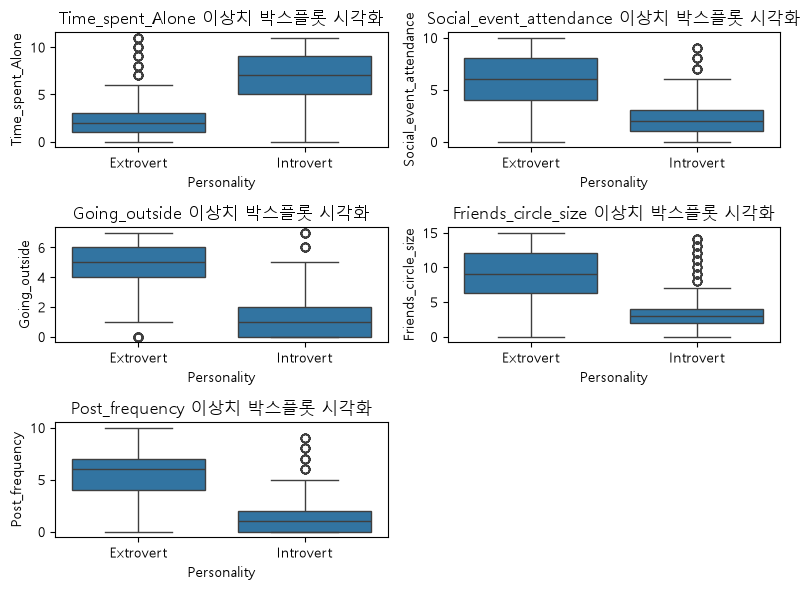

In [59]:
plt.figure(figsize = (8,6))

# 클래스별(타겟)로 숫자형 변수들의 값 분포 박스플롯
for i, col in enumerate(nf, 1):   # (nf,1) : 시작인덱스를 1로 정함(enumerate(객체,1))
    plt.subplot(3,2,i)
    sns.boxplot(x = target, y=col,data =df)   
    plt.title(f"{col} 이상치 박스플롯 시각화")

plt.tight_layout()
plt.show()

이상치 처리가 필요하다면 IQR 방식 등을 고려한다.

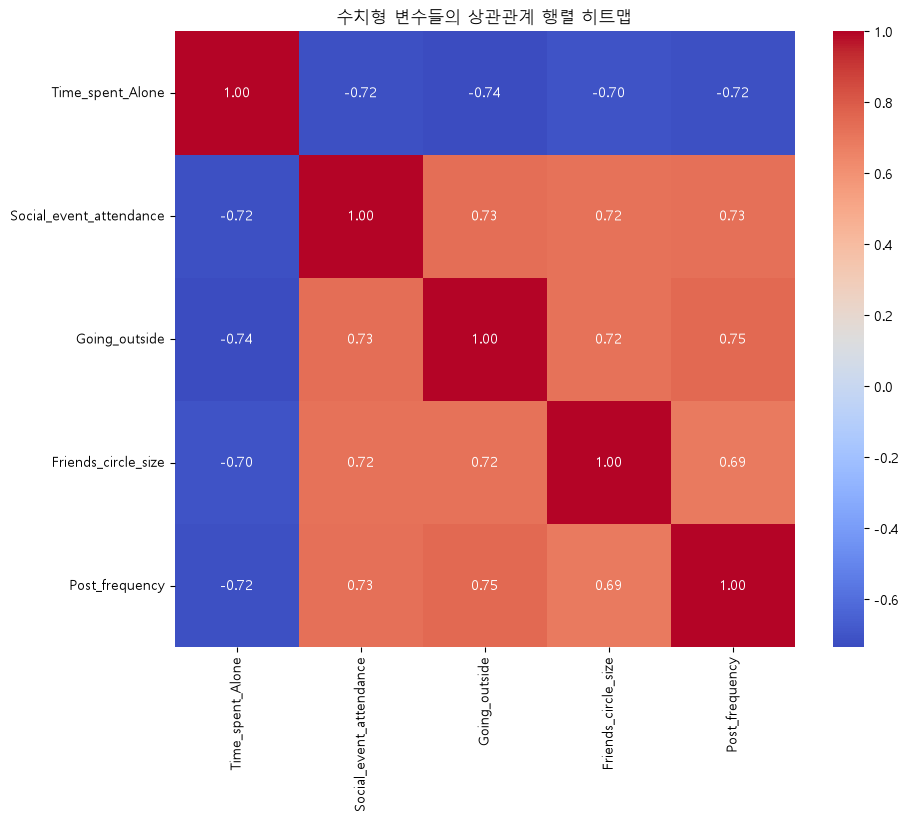

In [60]:
plt.figure(figsize=(10,8))

corr_matrix = df[nf].corr(numeric_only = True)  # 숫자형 변수들의 상관관계 계산
sns.heatmap(
    corr_matrix,    
    annot=True,     # 값 표시
    fmt = ".2f", 
    cmap='coolwarm'
    )

plt.title('수치형 변수들의 상관관계 행렬 히트맵')
plt.show()

VIF 지표 확인 : 변수들간의 중복성(다중공선성)을 확인  
5가 넘으면 변수 제거를 고려해본다.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant   # 상수항 추가

vif_df = df[nf].copy()
vif_df = vif_df.dropna()

vif_data = add_constant(vif_df)
vif_data

,const,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,1.0,4.0,4.0,6.0,13.0,5.0
1,1.0,9.0,0.0,0.0,0.0,3.0
2,1.0,9.0,1.0,2.0,5.0,2.0
3,1.0,0.0,6.0,7.0,14.0,8.0
4,1.0,3.0,9.0,4.0,8.0,5.0
...,...,...,...,...,...,...
2895,1.0,3.0,7.0,6.0,6.0,6.0
2896,1.0,3.0,8.0,3.0,14.0,9.0
2897,1.0,4.0,1.0,1.0,4.0,0.0
2898,1.0,11.0,1.0,3.0,2.0,0.0


In [62]:
# 각 변수별 분산팽창계수(VIF) 계산

vif = pd.DataFrame()

vif['feature'] = vif_data.columns
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

vif = vif[vif['feature'] != 'const']
vif

,feature,VIF
1,Time_spent_Alone,2.868138
2,Social_event_attendance,2.977068
3,Going_outside,3.235729
4,Friends_circle_size,2.693871
5,Post_frequency,2.994409


상관계수가 5가 넘으면 삭제를 고려해야 하지만 5가 넘는 컬럼은 없는 것으로 보인다.

In [63]:
# 교차표
ct = pd.crosstab(
    df['Stage_fear'],   # 행 (Stage_fear 로 집계)
    df[target]          # 열 (target변수로 집계)
)

ct

Personality,Extrovert,Introvert
Stage_fear,,
No,1380,110
Yes,111,1299


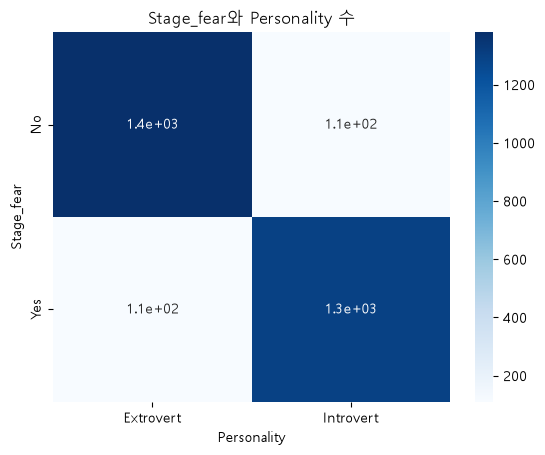

In [64]:
sns.heatmap(
    ct,
    annot= True,
    cmap = "Blues"
)
plt.title('Stage_fear와 Personality 수')
plt.show()

In [65]:
cf

['Stage_fear', 'Drained_after_socializing']

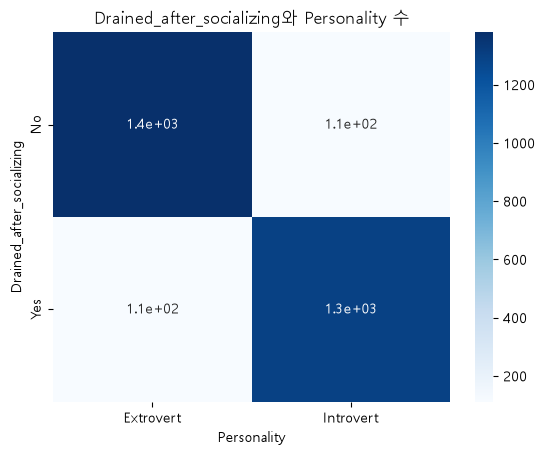

In [66]:
# 교차표
ct = pd.crosstab(df['Drained_after_socializing'],df[target])     
sns.heatmap(ct, annot= True, cmap = "Blues")
plt.title('Drained_after_socializing와 Personality 수')
plt.show()


In [67]:
ct

Personality,Extrovert,Introvert
Drained_after_socializing,,
No,1380,113
Yes,111,1296


범주형 변수 2개가 타겟에 영향을 주는것으로 보아 머신러닝 모델이 특성을 잘 캐치할 것으로 판단된다.

## 3. 데이터 전처리
- 타겟 인코딩
- 결측치가 있다면 대체 (SimpleImputer, 숫자형은 평균 or 중앙값, 범주형은 최빈값)
- 범주형 변수 인코딩
- 숫자형 변수 이상치는 제거한다면 IQR

In [68]:
# target 값 'Extrovert', 'Introvert' -> 0, 1
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# 어떤 클래스가 어떤 숫자로 바뀌었는지 확인
print(f"변환된 클래스 : {dict(zip(le.classes_,le.transform(le.classes_)))}")

변환된 클래스 : {'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


In [69]:
df[nf].describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [70]:
# 수치형 컬럼에 결측값이 있을시 결측값 처리
numaric_imputer = SimpleImputer(strategy='median') # 중앙값으로 대체
df[nf]= numaric_imputer.fit_transform(df[nf])

# 범주형 컬럼에 결측값이 있을시 결측값 처리
categorycal_imputer = SimpleImputer(strategy='most_frequent') # 최빈값으로 대체
df[cf]= categorycal_imputer.fit_transform(df[cf])

In [71]:
df = pd.get_dummies(df,                 # get_dummies : 원-핫 인코딩
                    columns = cf, 
                    drop_first= True)   # drop_first= True: 기준 카테고리를 하나 제거해서 중복 컬럼 제거


# 결과가 True / False 일 경우 0/1 정수형으로 변환
bool_cols = df.select_dtypes(include = bool).columns
df[bool_cols] = df[bool_cols].astype(int)  


In [72]:
df

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Personality,Stage_fear_Yes,Drained_after_socializing_Yes
0,4.0,4.0,6.0,13.0,5.0,0,0,0
1,9.0,0.0,0.0,0.0,3.0,1,1,1
2,9.0,1.0,2.0,5.0,2.0,1,1,1
3,0.0,6.0,7.0,14.0,8.0,0,0,0
4,3.0,9.0,4.0,8.0,5.0,0,0,0
...,...,...,...,...,...,...,...,...
2895,3.0,7.0,6.0,6.0,6.0,0,0,0
2896,3.0,8.0,3.0,14.0,9.0,0,0,0
2897,4.0,1.0,1.0,4.0,0.0,1,1,1
2898,11.0,1.0,3.0,2.0,0.0,1,1,1


In [73]:
encoded_columns = [col for col in df.columns if col != target]

# 수치형 컬럼의 이상치 IQR 방식 활용 제거
for cor in nf:
    Q1 = df[col].quantile(0.25) # 1사분위수
    Q3 = df[col].quantile(0.75) # 3사분위수
    IQR = Q3 - Q1
    lower_bound = (Q1-1.5)*IQR # 하한선
    upper_bound = (Q3+1.5)*IQR # 상한선
    # clip() : 값이 특정 범위를 벗어나지 않도록 잘라냄
    df[col] = df[col].clip(lower= lower_bound, upper= upper_bound) # 범위 밖 값

## 4. 모델 구현

In [74]:
X = df.drop(columns=[target])   # 입력데이터
y = df[target]                  # 정답 데이터

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size= 0.2,     #80:20
    stratify = y,       #train/test 클래스 비율을 비슷하게유지
    random_state = 42
)
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2320
580
2320
580


처음에는 LogisticRegression
검증 지표 : Accuracy, Precison, Recall, F1-score

학습 데이터 셋 정확도 : 0.9370689655172414
학습 데이터 셋 정밀도 : 0.9414374445430346
학습 데이터 셋 재현율 : 0.92988606485539
학습 데이터 셋 F1_Score : 0.935626102292769
테스트 데이터 셋 정확도 : 0.9172413793103448
테스트 데이터 셋 정밀도 : 0.9397163120567376
테스트 데이터 셋 재현율 : 0.8952702702702703
테스트 데이터 셋 F1_Score : 0.916955017301038
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



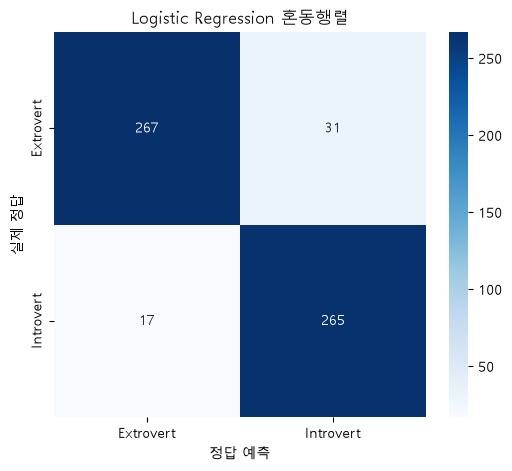

In [75]:
from sklearn.metrics import (accuracy_score,    # 정확도
                             f1_score,          # f1score
                             precision_score,   # 정밀도
                             recall_score,      # 재헌율
                             confusion_matrix,  
                             classification_report)

# LogisticRegression 모델 정의 및 학습 (반복 1000번)
lr = LogisticRegression(
    random_state=42,
    max_iter= 1000
)
lr.fit(X_train,y_train)

y_pred_train = lr.predict(X_train)
y_pred = lr.predict(X_test)

print(f"학습 데이터 셋 정확도 : {accuracy_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 정밀도 : {precision_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 재현율 : {recall_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 F1_Score : {f1_score(y_pred_train,y_train)}")

print('===================')
print(f"테스트 데이터 셋 정확도 : {accuracy_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 정밀도 : {precision_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 재현율 : {recall_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 F1_Score : {f1_score(y_pred,y_test)}")

print(classification_report(y_test,y_pred,target_names=le.classes_))
cm = confusion_matrix(y_test,y_pred)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm,  
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("정답 예측")
plt.ylabel("실제 정답")
plt.title('Logistic Regression 혼동행렬')
plt.show()

LogisticRegression 사용 결과 92% 정도의 정확도로 양호한 성적

RandomForestClassifier : DecisionTree가 여러개 결합된 형태의 앙상블 모델

학습 데이터 셋 정확도 : 0.9849137931034483
학습 데이터 셋 정밀도 : 0.9955634427684117
학습 데이터 셋 재현율 : 0.9739583333333334
학습 데이터 셋 F1_Score : 0.9846423870118473
테스트 데이터 셋 정확도 : 0.9017241379310345
테스트 데이터 셋 정밀도 : 0.9078014184397163
테스트 데이터 셋 재현율 : 0.89198606271777
테스트 데이터 셋 F1_Score : 0.8998242530755711


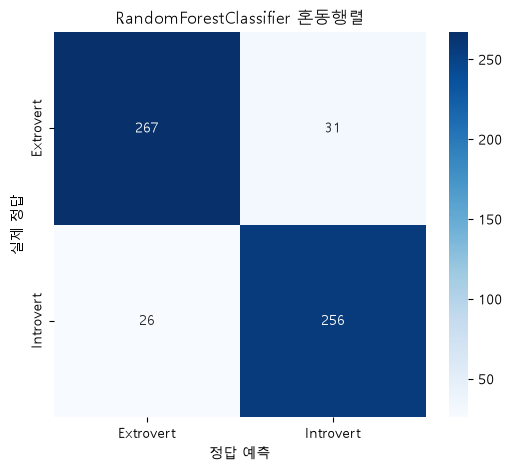

In [76]:
# RandomForestClassifier모델 정의 및 학습

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train,y_train)

y_pred_train = rfc.predict(X_train)
y_pred = rfc.predict(X_test)

print(f"학습 데이터 셋 정확도 : {accuracy_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 정밀도 : {precision_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 재현율 : {recall_score(y_pred_train,y_train)}")
print(f"학습 데이터 셋 F1_Score : {f1_score(y_pred_train,y_train)}")

print('===================')
print(f"테스트 데이터 셋 정확도 : {accuracy_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 정밀도 : {precision_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 재현율 : {recall_score(y_pred,y_test)}")
print(f"테스트 데이터 셋 F1_Score : {f1_score(y_pred,y_test)}")

cm = confusion_matrix(y_test,y_pred)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm,  
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("정답 예측")
plt.ylabel("실제 정답")
plt.title('RandomForestClassifier 혼동행렬')
plt.show()

RandomForestClassifier 모델 사용 결과 학습 지표가 검증 지표보다 월등히 높게 나오는걸로 봐서 과적합이 의심된다.  
하이퍼파라미터 튜닝이 필요해보임.

### LogisticRegression 특성 중요도 분석

In [77]:
lr.coef_[0]

array([-0.01401793, -0.02196981, -0.07698559,  0.04878873, -0.09639131,
        2.42491065,  2.49519062])

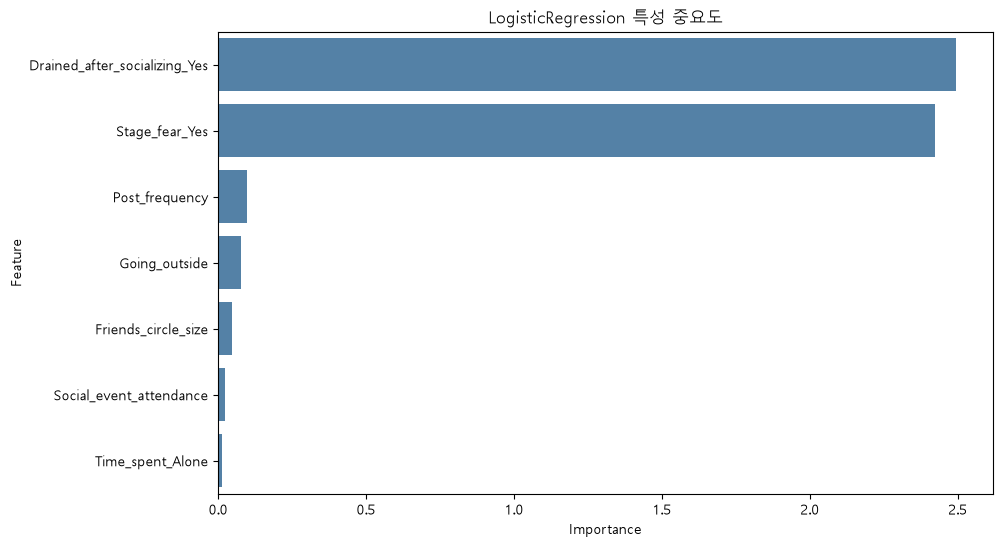

In [78]:
# 이진 분류 / 다중 분류 일 경우 특성 중요도 뽑기

if len(lr.coef_) == 1:
    importances = np.abs(lr.coef_[0])
else:  # 다중 분류
    importances = np.mean(np.abs(lr.coef_), axis = 0)  # 행을 기준(각 특성별로)으로 클래스들의 평균 중요도

# 특성명과 중요도를 중요도 기준으로 내림차순하여 데이터 프레임으로 생성
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by = 'Importance', ascending= False)


# 특성 중요도 막대그래프 시각화
plt.figure(figsize =(10,6))
sns.barplot(x='Importance',
            y= 'Feature',
            data= feature_importance,
            color = 'steelblue')
plt.title("LogisticRegression 특성 중요도")
plt.show()

LogisticRegression은 범주형 변수들을 중요하게 판단함.

In [79]:
rfc.feature_importances_

array([0.14906085, 0.15135297, 0.11367688, 0.06097374, 0.12672223,
       0.17216838, 0.22604494])

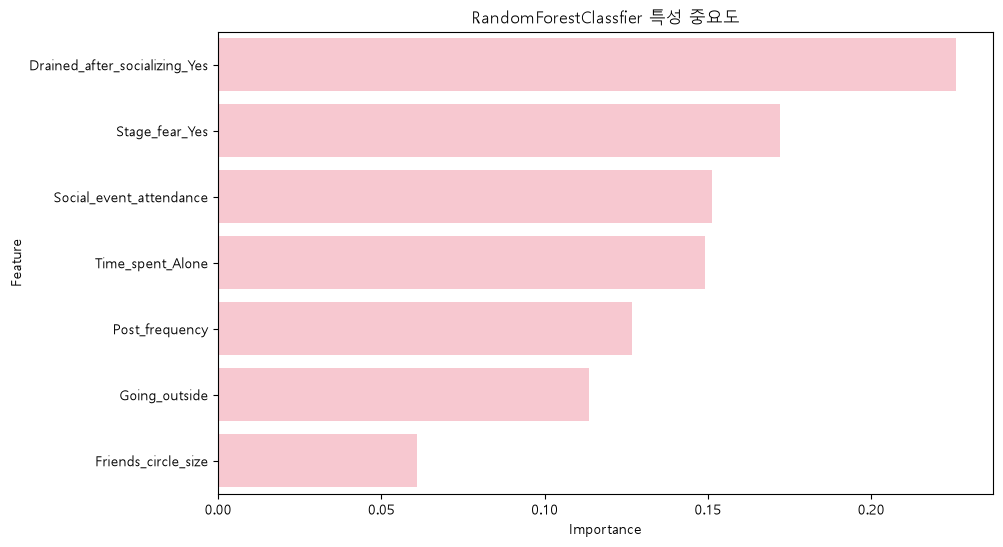

In [80]:
# RandomForestClassfier 특성명과 중요도를 중요도 기준으로 내림차순하여 데이터 프레임으로 생성
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rfc.feature_importances_
}).sort_values(by = 'Importance', ascending= False)


# 특성 중요도 막대그래프 시각화
plt.figure(figsize =(10,6))
sns.barplot(x='Importance',
            y= 'Feature',
            data= feature_importance,
            color = 'pink')
plt.title("RandomForestClassfier 특성 중요도")
plt.show()

RandomForestClassfier도 범주형 변수를 가장 중요하게 판단하였으나, 수치형 변수들도 적절한 중요도로 판단함

## 6. 분류모델 고도화
- RandomizedSearchCV 활용하여 하이퍼파라미터 값 수정
    - LogisticRegression
        - C : 규제 강도
        - solver : 최적화 알고리즘
    - RandomForestClassifier
        - n_estimators : 트리개수
        - max_depth : 각 트리의 최대 깊이
        - min_saples_split : 노드를 나누기 위한 최소 샘플 수

In [81]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# 비교할 모델과 하이퍼파라미터 후보를 딕셔너리 형태로 관리
models = {
    'logistic' : {
        'model': Pipeline([
            ('scaler', StandardScaler()),  # 표준화 작업 (LogisticRegression만 적용)
            ('model',LogisticRegression(max_iter= 1000, random_state= 42))
        ]),
        'params': {
            'model__C' : np.logspace(-4,4,20),  # 규제 강도 후보(10^-4 ~ 10^4 까지 데이터 20개)
            'model__solver' : ['lbfgs','liblinear'] # 최적화 알고리즘 후보들
        }
    },
    'rf' : {
        'model' : RandomForestClassifier(random_state= 42),
        'params' : {
            'n_estimators' : [100, 150],    # 트리 개수
            'max_depth' : [None,10],        # 트리 깊이
            'min_samples_split': [2,5]      # 노드 분할 최소 샘플수
        }
    }
}

results = []            # 모델별 성능 결과
optimized_model = {}    # 최적화된 모델


# 모델별 하이퍼파라미터 탐색
for model_name, mp in models.items():
    # 전체 조합수 보다 n_iter가 크면 오류 발생할 수 있으므로 20보다 작을때만 파라미터 탐색수 사용하고 아니면 20
    n_iter = min(20, len(list(ParameterGrid(mp['params'])))) 

    clf = RandomizedSearchCV(
        estimator = mp['model'],            # 탐색할 모델
        param_distributions = mp['params'], # 탐색할 하이퍼파라미터 후보
        n_iter= n_iter,                     # 랜덤하게 시도할 조합 수
        cv =3,                              # 3fold 교차 검증
        scoring = 'f1_weighted',            # 평가 기준 : 가중 평균 f1-score
        n_jobs = 1,                         # 사용할 cpu 코어 수 (-1이 들어오면 자동으로 병렬배치)
        random_state = 42                   
    )
    clf.fit(X_train,y_train)

    y_test_pred = clf.best_estimator_.predict(X_test)           # 최적 도멜로 테스트 데이터 예측
    test_f1 = f1_score(y_test,y_test_pred,average='weighted')   # 테스트 F1스코어 (가중 평균)

    optimized_model[model_name] = clf.best_estimator_           # 최적 모델 저장

    results.append({
        'model' : model_name,
        'best_cv_score': clf.best_score_,
        'test_f1' : test_f1,
        'best_params' : clf.best_params_
    })

df_results = pd.DataFrame(results).sort_values(by='test_f1',ascending= False)
df_results

,model,best_cv_score,test_f1,best_params
0,logistic,0.938802,0.917248,"{'model__solver': 'lbfgs', 'model__C': 0.00069..."
1,rf,0.938802,0.917248,"{'n_estimators': 100, 'min_samples_split': 2, ..."


## 7. Pipeline 기반 모델 비교
- Pipeline, ColumnTransformer
    - 전처리, 모델 학습 과정을 하나로 묶어 사용
    - 여러 모델을 같은 전처리 흐름으로 공정하게 비교

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay


# 최초 데이터인 original_df 사용
advanced_X = original_df.drop(columns= [target])
advanced_y = original_df[target]

# 타겟 데이터를 숫자로 변환
target_encoder = LabelEncoder()
advanced_y_encoded = target_encoder.fit_transform(advanced_y)

# 데이터 타입 기준으로 컬럼 선택후 숫자형/범주형 컬럼 분리
numeric_features = advanced_X.select_dtypes(include = np.number).columns.tolist()
categorical_features = advanced_X.select_dtypes(include = 'str').columns.tolist()

X_train_raw,X_test_raw,y_train_raw,y_test_raw = train_test_split(
    advanced_X,
    advanced_y_encoded,
    test_size= 0.2,
    stratify = advanced_y_encoded,
    random_state= 42
)


print(f"numeric_features : {numeric_features}")
print(f"categorical_features : {categorical_features}")


numeric_features : ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features : ['Stage_fear', 'Drained_after_socializing']


## 8. 전처리 파이프라인 만들기
- 숫자형 변수 : 결측값을 중앙값으로 채우고, 스케일링 적용
- 범주형 변수 : 결측값을 최빈값으로 채우고, 원-핫 인코딩 적용

In [83]:
# 전처리 파이프라인 함수

def make_preprocessor():
    try:
        onehot = OneHotEncoder(
            drop = 'first',             # 첫번째 범주는 제거하여 중복 정보 감소
            handle_unknown='ignore',    # 학습때 없었던 범주가 나와도 에러 발생하지 않음
            sparse_output=False
            )
    except TypeError:
        onehot = OneHotEncoder(drop = 'first', handle_unknown='ignore', sparse=False) # 구버전 문법(에러 회피용)
    # 숫자형 변수 전처리 파이프라인 
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # 결측치는 중앙값으로 
        ('scaler', StandardScaler())                    # 평균 0, 표준 편차1 종모양 스케일링
    ])
    # 범주형 변수 전처리 파이프라인
    categorycal_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),   # 결측치는 최빈값으로
        ('onehot', onehot)                                      # 원-핫 인코딩
    ])
    
    # 컬럼 이름별로 다른 전처리를 적용
    preprocessor = ColumnTransformer([
        ('num',numeric_pipe,numeric_features),          # 숫자형 컬림에는 numeric_pipe 실행 
        ('cat',categorycal_pipe,categorical_features)   # 범주형 컬럼에는 categorycal_pipe 실행
    ])

    return preprocessor  # 전처리 완료된 객체 반환

In [84]:
clf.best_params_

{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}

## 9. 여러 모델을 같은 기준으로 비교
- LogisticRegression, RandomForest, GradientBoosting(이전 모델의 오차를 보완하며 학습하는 부스팅 계열 모델)

In [ ]:
advanced_models = {
    'LogisticRegression' : LogisticRegression(max_iter = 1000,random_state= 42),
    'RandomForest' : RandomForestClassifier(n_estimators= 150, min_samples_split= 2, max_depth = 10, random_state=42),
    'GradientBoosting' : GradientBoostingClassifier(random_state=42)

}

advanced_results = []   # 모델별 평가 결과
trained_pipelines = {}  # 학습 완료된 파이프라인

for name, estimator in advanced_models.items():

    # 전처리 + 모델을 하나의 파이프라인으로 묶기
    pipe = Pipeline([
        ('preprocess',make_preprocessor()),
        ('model',estimator)
    ])

    pipe.fit(X_train_raw, y_train_raw)

    y_pred = pipe.predict(X_test_raw)
    # 평가 결과 저장
    advanced_results.append({
        'model' : name,
        'accuracy' : accuracy_score(y_test_raw, y_pred),
        'precision_weighted' : precision_score(y_test_raw, y_pred, average='weighted'),  # 'weighted : 가중평균()
        'recall_weighted' : recall_score(y_test_raw, y_pred, average='weighted'),
        'f1_weighted' : f1_score(y_test_raw, y_pred, average='weighted')
    })

    trained_pipelines[name]= pipe

# f1 점수 기준으로 정렬
advanced_results_df = pd.DataFrame(advanced_results).sort_values(by='f1_weighted',ascending=False)

advanced_results_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,0.917241,0.918324,0.917241,0.917248
2,GradientBoosting,0.917241,0.918324,0.917241,0.917248
1,RandomForest,0.915517,0.916750,0.915517,0.915521


In [90]:
df.columns

Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency', 'Personality',
       'Stage_fear_Yes', 'Drained_after_socializing_Yes'],
      dtype='str')

In [93]:
best_model_name = advanced_results_df.iloc[1]['model']
best_pipline = trained_pipelines[best_model_name]


sample_person = pd.DataFrame([{
    'Time_spent_Alone' : 3,
    'Social_event_attendance' : 7,
    'Going_outside' : 6,
    'Friends_circle_size' : 10,
    'Post_frequency': 7,
    'Stage_fear': 'Yes',
    'Drained_after_socializing' : 'No'
}])

sample_pred = best_pipline.predict(sample_person)

sample_pred_name = target_encoder.inverse_transform(sample_pred)

print(f"예측된 성격 유형 : {sample_pred_name[0]}, 예측한 클래스 번호 : {sample_pred}")

예측된 성격 유형 : Extrovert, 예측한 클래스 번호 : [0]
